# Análisis de Resultados

In [78]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud
import json
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA


## 1. Summarization

## 2. Clustering

In [72]:
output_csv_path = "2_Modelos/clustering/clustering_results_consolidated.csv"
labels_npy_path = "2_Modelos/clustering/cluster_labels.npy"
embeddings_npy_path = "2_Modelos/clustering/embeddings.npy"

In [73]:
 # Cargar los resultados
df_results = pd.read_csv(output_csv_path)
print(f"✓ Cargados {len(df_results)} registros desde el CSV.")

# Extraer las columnas necesarias
cluster_labels = df_results['cluster_label'].values
embeddings_2d = df_results[['pca_dim_1', 'pca_dim_2']].values

# El DataFrame original 'df' ahora es 'df_results'
df = df_results

✓ Cargados 434 registros desde el CSV.


### Evaluación de calidad

In [76]:
metrics = {}
embeddings = np.load(embeddings_npy_path)
    
# Filtrar outliers (-1) para las métricas
mask = cluster_labels != -1
filtered_embeddings = embeddings[mask]
filtered_labels = cluster_labels[mask]

if len(set(filtered_labels)) >= 2:
    # Silhouette Score
    silhouette = silhouette_score(filtered_embeddings, filtered_labels)
    print(f"\nSilhouette Score (384D): {silhouette:.4f}")
    
    # Davies-Bouldin Index
    davies_bouldin = davies_bouldin_score(filtered_embeddings, filtered_labels)
    print(f"Davies-Bouldin Index (384D): {davies_bouldin:.4f}")
    
    metrics = {
        'silhouette_score': float(silhouette),
        'davies_bouldin_index': float(davies_bouldin),
        'n_clusters': len(set(filtered_labels)),
        'n_outliers': int((cluster_labels == -1).sum()),
        'outlier_percentage': float((cluster_labels == -1).sum() / len(cluster_labels) * 100)
    }
    
    with open("2_Modelos/clustering/clustering_metrics.json", 'w') as f:
        json.dump(metrics, f, indent=2)
    
    print(f"\n✓ Métricas guardadas en {'2_Modelos/clustering/clustering_metrics.json'}")


Silhouette Score (384D): 0.0517
Davies-Bouldin Index (384D): 2.1143

✓ Métricas guardadas en 2_Modelos/clustering/clustering_metrics.json


### Visualización 

In [81]:
embeddings_full = np.load(embeddings_npy_path)
pca_plot = PCA(n_components=2, random_state=42)
pca_plot.fit(embeddings_full)
variance_explained = pca_plot.explained_variance_ratio_.sum()

/var/folders/p9/c7lshh9n1j55x6_b26v_sx1h0000gn/T/ipykernel_59052/888378394.py:15: UserWarning: You passed a edgecolor/edgecolors ('white') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(


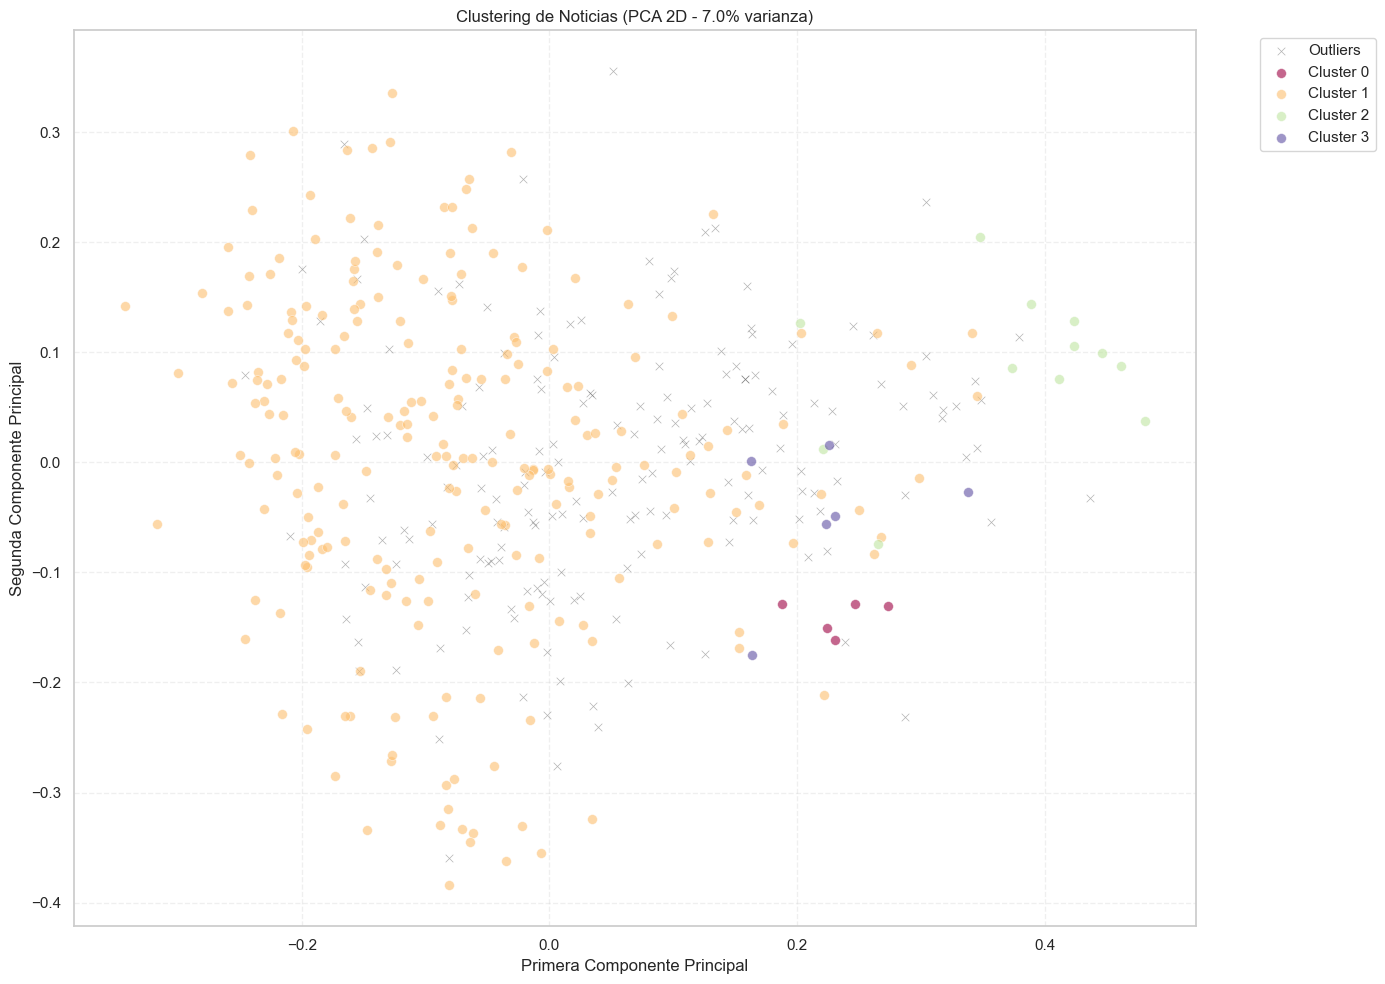

✓ Visualización guardada en 2_Modelos/clustering/clusters_visualization.png


In [83]:
plt.figure(figsize=(14, 10))
unique_labels = sorted(set(cluster_labels))
n_clusters = len([l for l in unique_labels if l != -1])
colors = plt.cm.Spectral(np.linspace(0, 1, n_clusters))
color_map = {l: colors[i] for i, l in enumerate([l for l in unique_labels if l != -1])}
color_map[-1] = 'black'

for label in unique_labels:
    mask = cluster_labels == label
    marker = 'x' if label == -1 else 'o'
    label_text = 'Outliers' if label == -1 else f'Cluster {label}'
    alpha = 0.3 if label == -1 else 0.6
    size = 30 if label == -1 else 50
    
    plt.scatter(
        embeddings_2d[mask, 0],
        embeddings_2d[mask, 1],
        c=[color_map[label]],
        label=label_text,
        marker=marker,
        alpha=alpha,
        s=size,
        edgecolors='white',
        linewidth=0.5
    )

plt.xlabel('Primera Componente Principal')
plt.ylabel('Segunda Componente Principal')
plt.title(f'Clustering de Noticias (PCA 2D - {variance_explained:.1%} varianza)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True)
plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()

viz_path = "2_Modelos/clustering/clusters_visualization.png"
plt.savefig(viz_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Visualización guardada en {viz_path}")
plt.close()

### Análisis de contenido

In [84]:

analysis = []
df_with_labels = df_results # Usamos el DataFrame cargado

for cluster_id in sorted(set(cluster_labels)):
    if cluster_id == -1:
        continue
    
    cluster_docs = df_with_labels[df_with_labels['cluster_label'] == cluster_id]
    sample_titles = cluster_docs['title'].head(3).tolist()
    top_sources = cluster_docs['source'].value_counts().head(2)
    
    cluster_info = {
        'cluster_id': int(cluster_id),
        'size': len(cluster_docs),
        'percentage': float(len(cluster_docs) / len(df_results) * 100),
        'sample_titles': sample_titles,
        'top_sources': top_sources.to_dict()
    }
    analysis.append(cluster_info)
    
    print(f"\nCluster {cluster_id} (Tamaño: {len(cluster_docs)}, {cluster_info['percentage']:.1f}%):")
    for i, title in enumerate(sample_titles, 1):
        print(f"  {i}. {title}")
    if not top_sources.empty:
        print(f"  Fuentes principales: {', '.join(top_sources.index.tolist())}")

# Análisis de outliers
outliers = df_with_labels[df_with_labels['cluster_label'] == -1]
if len(outliers) > 0:
    print(f"\nOutliers (Noticias únicas - Total: {len(outliers)}):")
    for i, (_, row) in enumerate(outliers.head(2).iterrows(), 1):
        print(f"  {i}. {row['title']}")

# Guardar análisis
analysis_path =  "2_Modelos/clustering/cluster_analysis.json"
with open(analysis_path, 'w', encoding='utf-8') as f:
    json.dump(analysis, f, indent=2, ensure_ascii=False)
print(f"\n✓ Análisis guardado en {analysis_path}")


Cluster 0 (Tamaño: 5, 1.2%):
  1. Bethesda Announces Fallout 4 Anniversary Edition, Confirms Nintendo Switch 2 Version for 2026
  2. Bethesda's Fallout Day stream reveals Fallout 4 Anniversary Edition, confirms the 2015 RPG is coming to Switch 2, and no New Vegas remake, but here's a collectors bundle instead
  3. Bethesda celebrates Fallout Day with a host of announcements, including a Fallout 4 Anniversary Edition and Nintendo Switch 2 Edition, a native Fallout 76 release for PS5 and Xbox Series X, and more
  Fuentes principales: IGN, GamesRadar+

Cluster 1 (Tamaño: 232, 53.5%):
  1. Bruce Springsteen lent helping hand to director's family after Los Angeles wildfires
  2. Trump backs off planned surge of federal agents into San Francisco after talking to the mayor
  3. Xbox Game Pass October Wave 2 is wild: The Outer Worlds 2, PowerWash 2, Football Manager 26, and a mech farming sim. Yes, really
  Fuentes principales: The Times of India, Memeorandum.com

Cluster 2 (Tamaño: 12, 2.8%)

## 3. Sentiment Analysis

### Análisis del dataset utilizado

In [ ]:
nltk.download("stopwords")
stop_words = set(stopwords.words("english"))

def clean_text(text):
    if pd.isna(text):
        return ""
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)  # solo letras y espacios
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/arielamishaancohen/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [48]:
sentiment_data = pd.read_csv("1_Data/processed/sentiment_data.csv")
sentiment_data.head()

,title,description,content,full_content,source,author,publishedAt,url,sentiment
0,Brockton mayoral race heats up as Derenoncourt...,Did a finalist to be Brockton's next mayor duc...,BROCKTON Did a finalist to be Brockton's next ...,BROCKTON — Did a finalist to be Brockton's nex...,Enterprise News,"Chris Helms, The Enterprise",2025-10-23T18:06:11Z,https://www.enterprisenews.com/story/news/poli...,neutral
1,Bruce Springsteen lent helping hand to directo...,"Bruce Springsteen, the legendary musician, dem...",<ul><li>News</li>\r\n<li>Bruce Springsteen len...,"Bruce Springsteen, the legendary musician, dem...",The Times of India,IANS,2025-10-23T18:05:51Z,https://timesofindia.indiatimes.com/entertainm...,neutral
2,Binance Founder Changpeng Zhao Receives Pardon...,U.S. President Donald Trump has granted Binanc...,U.S. President Donald Trump has granted Binanc...,Advertisement\n\nU.S. President Donald Trump h...,ZyCrypto,Brenda Ngari,2025-10-23T18:03:17Z,https://zycrypto.com/binance-founder-changpeng...,neutral
3,A Mandatory Paper Bag Fee May Be Coming to Phi...,Check phillymag.com each morning Monday throug...,"NewsPlus, Philly mob documentary makes a big s...",A Mandatory Paper Bag Fee May Be Coming to Phi...,phillymag.com,Victor Fiorillo,2025-10-23T18:03:12Z,https://www.phillymag.com/news/2025/10/23/plas...,neutral
4,Wilco and Billy Bragg to Perform Mermaid Avenu...,"""Mermaid Avenue Live"" is set to take place at ...",Wilco and Billy Bragg have announced they will...,Wilco and Billy Bragg have announced they will...,Consequence.net,Eddie Fu,2025-10-23T18:02:51Z,https://consequence.net/2025/10/wilco-billy-br...,neutral


In [49]:
sentiment_data['full_content'] = sentiment_data['full_content'].apply(clean_text)

In [50]:
# 2) INFORMACIÓN GENERAL
print("Número de filas y columnas:", sentiment_data.shape)
print("\nColumnas:", sentiment_data.columns.tolist())
print("\nTipos de datos:")
print(sentiment_data.dtypes)
print("\nValores nulos por columna:")
print(sentiment_data.isnull().sum())

Número de filas y columnas: (611, 9)

Columnas: ['title', 'description', 'content', 'full_content', 'source', 'author', 'publishedAt', 'url', 'sentiment']

Tipos de datos:
title           object
description     object
content         object
full_content    object
source          object
author          object
publishedAt     object
url             object
sentiment       object
dtype: object

Valores nulos por columna:
title             0
description       0
content           0
full_content      0
source            0
author          110
publishedAt       0
url               0
sentiment         0
dtype: int64


/var/folders/p9/c7lshh9n1j55x6_b26v_sx1h0000gn/T/ipykernel_59052/598873849.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="sentiment", data=sentiment_data, palette=["red","gray","green"])


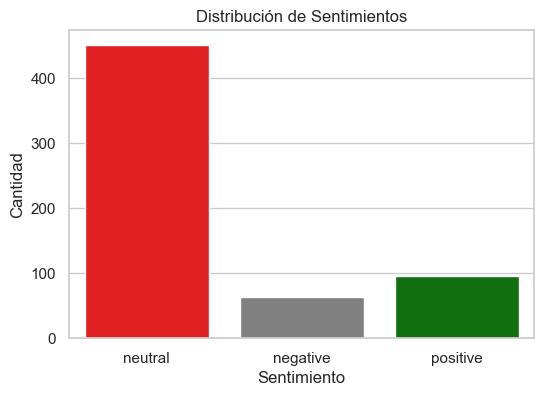

sentiment
neutral     0.738134
positive    0.157119
negative    0.104746
Name: proportion, dtype: float64


In [51]:
# 3) DISTRIBUCIÓN DE SENTIMIENTOS

sns.set(style="whitegrid")

plt.figure(figsize=(6,4))
sns.countplot(x="sentiment", data=sentiment_data, palette=["red","gray","green"])
plt.title("Distribución de Sentimientos")
plt.xlabel("Sentimiento")
plt.ylabel("Cantidad")
plt.show()

# Proporciones
print(sentiment_data["sentiment"].value_counts(normalize=True))

/var/folders/p9/c7lshh9n1j55x6_b26v_sx1h0000gn/T/ipykernel_59052/2461955661.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_domains.values, y=top_domains.index, palette="viridis")


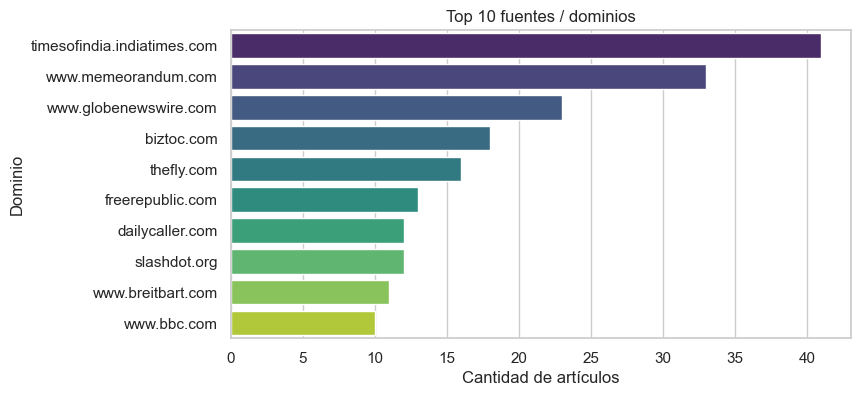

domain
timesofindia.indiatimes.com    41
www.memeorandum.com            33
www.globenewswire.com          23
biztoc.com                     18
thefly.com                     16
freerepublic.com               13
dailycaller.com                12
slashdot.org                   12
www.breitbart.com              11
www.bbc.com                    10
Name: count, dtype: int64

In [52]:
# 4) FUENTES / URL
# Si tienes columna 'url', podemos ver top dominios
from urllib.parse import urlparse

if "url" in sentiment_data.columns:
    sentiment_data["domain"] = sentiment_data["url"].apply(lambda x: urlparse(str(x)).netloc)
    top_domains = sentiment_data["domain"].value_counts().head(10)
    
    plt.figure(figsize=(8,4))
    sns.barplot(x=top_domains.values, y=top_domains.index, palette="viridis")
    plt.title("Top 10 fuentes / dominios")
    plt.xlabel("Cantidad de artículos")
    plt.ylabel("Dominio")
    plt.show()
    
    display(top_domains)

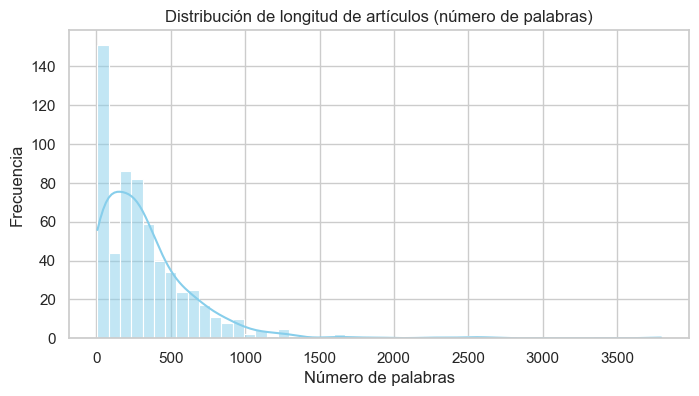

Estadísticas descriptivas de longitud de artículos:


count     611.000000
mean      333.934534
std       348.833793
min         7.000000
25%        89.500000
50%       257.000000
75%       454.000000
max      3795.000000
Name: content_len, dtype: float64

In [53]:
# 5) LONGITUD DE LOS TEXTOS
sentiment_data["content_len"] = sentiment_data["full_content"].fillna("").str.split().apply(len)

plt.figure(figsize=(8,4))
sns.histplot(sentiment_data["content_len"], bins=50, kde=True, color="skyblue")
plt.title("Distribución de longitud de artículos (número de palabras)")
plt.xlabel("Número de palabras")
plt.ylabel("Frecuencia")
plt.show()

print("Estadísticas descriptivas de longitud de artículos:")
display(sentiment_data["content_len"].describe())

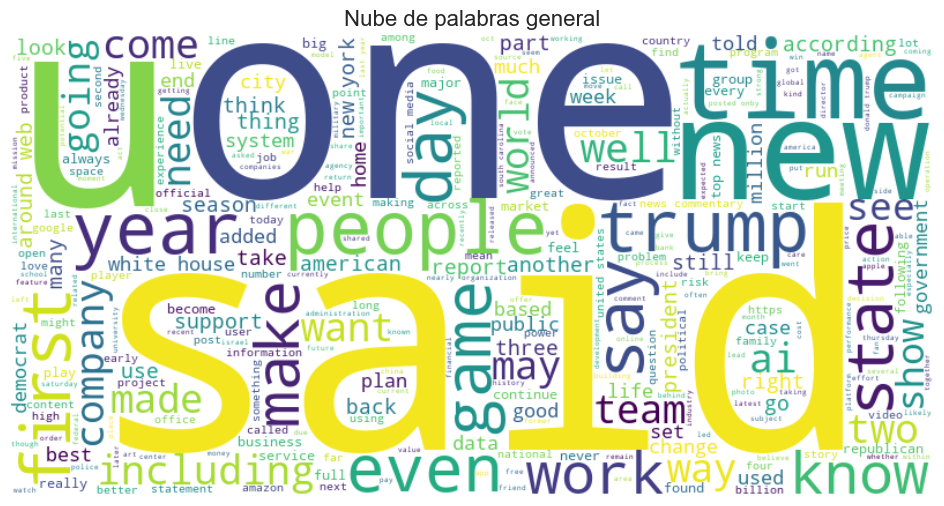

In [54]:
# 6) NUBE DE PALABRAS GENERAL
from wordcloud import WordCloud

all_text = " ".join(sentiment_data["full_content"].fillna("").astype(str))

wc = WordCloud(width=800, height=400, background_color="white", max_words=300).generate(all_text)

plt.figure(figsize=(12,6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Nube de palabras general", fontsize=16)
plt.show()

In [55]:
# 7) ARTÍCULOS MÁS LARGOS / CORTOS
print("5 artículos más largos:")
display(sentiment_data.nlargest(5, "content_len")[["title","content_len","sentiment"]])

print("\n5 artículos más cortos:")
display(sentiment_data.nsmallest(5, "content_len")[["title","content_len","sentiment"]])

5 artículos más largos:


,title,content_len,sentiment
164,(no subject),3795,negative
247,The mad king's digital killswitch,2609,neutral
177,8 Approaches To Make A Living In The Online Ga...,2498,positive
319,Daily Press Briefing by the Office of the Spok...,2263,neutral
167,Is Secret Service chief committed to reforming...,1881,positive



5 artículos más cortos:


,title,content_len,sentiment
71,Λευκός Οίκος: Ο Τραμπ θα συναντήσει την επόμεν...,7,neutral
427,Στα άκρα η κόντρα ΗΠΑ-Ισραήλ: «Αν ο Νετανιάχου...,9,neutral
151,Eric Adams to endorse Andrew Cuomo in NYC mayo...,14,neutral
152,Duffy warns of travel disruptions as air traff...,14,neutral
154,DC police detained man for protesting National...,14,neutral


In [56]:
# 8) PALABRAS MÁS FRECUENTES POR SENTIMIENTO
from collections import Counter
import re

def top_words(df, label, col_text="full_content", n=20):
    text = " ".join(df[df["sentiment"] == label][col_text].fillna("").astype(str))
    # limpiar
    text = re.sub(r"\W+", " ", text.lower())
    words = text.split()
    counter = Counter(words)
    return counter.most_common(n)

for s in sentiment_data["sentiment"].unique():
    print(f"Top palabras en {s}:")
    display(top_words(sentiment_data, s))

Top palabras en neutral:


[('said', 873),
 ('news', 653),
 ('one', 603),
 ('new', 569),
 ('like', 469),
 ('also', 449),
 ('trump', 440),
 ('time', 398),
 ('us', 394),
 ('year', 387),
 ('would', 357),
 ('first', 351),
 ('get', 335),
 ('people', 299),
 ('two', 278),
 ('state', 270),
 ('world', 266),
 ('could', 260),
 ('around', 255),
 ('top', 253)]

Top palabras en negative:


[('new', 161),
 ('said', 148),
 ('com', 114),
 ('fallout', 107),
 ('trump', 100),
 ('news', 99),
 ('ai', 82),
 ('one', 80),
 ('us', 78),
 ('like', 78),
 ('would', 71),
 ('free', 71),
 ('also', 70),
 ('oct', 68),
 ('federal', 67),
 ('first', 63),
 ('power', 63),
 ('get', 62),
 ('york', 61),
 ('game', 57)]

Top palabras en positive:


[('said', 167),
 ('trump', 166),
 ('news', 144),
 ('one', 139),
 ('new', 121),
 ('people', 119),
 ('house', 114),
 ('like', 112),
 ('president', 110),
 ('also', 102),
 ('white', 101),
 ('would', 85),
 ('time', 84),
 ('even', 79),
 ('top', 77),
 ('could', 76),
 ('online', 73),
 ('media', 71),
 ('company', 67),
 ('wing', 64)]

/var/folders/p9/c7lshh9n1j55x6_b26v_sx1h0000gn/T/ipykernel_59052/1926717110.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


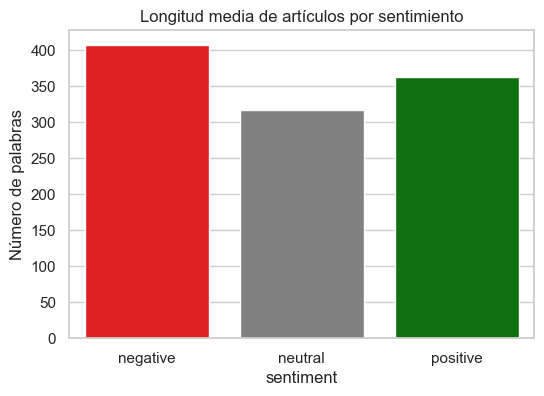

In [57]:
# 9) LONGITUD MEDIA DE ARTÍCULOS POR SENTIMIENTO
plt.figure(figsize=(6,4))
sns.barplot(
    x=sentiment_data.groupby("sentiment")["content_len"].mean().index,
    y=sentiment_data.groupby("sentiment")["content_len"].mean().values,
    palette=["red","gray","green"]
)
plt.title("Longitud media de artículos por sentimiento")
plt.ylabel("Número de palabras")
plt.show()

/var/folders/p9/c7lshh9n1j55x6_b26v_sx1h0000gn/T/ipykernel_59052/3334435604.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="sentiment", y="content_len", data=sentiment_data, palette=["red","gray","green"])


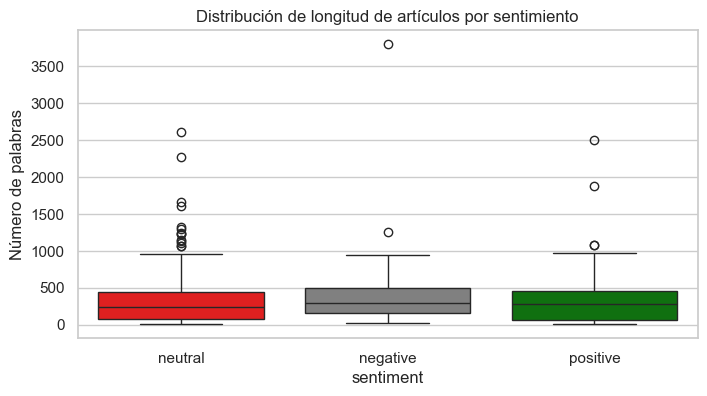

In [58]:
# 10) DISTRIBUCIÓN DE PALABRAS (BOXPLOT) POR SENTIMIENTO
plt.figure(figsize=(8,4))
sns.boxplot(x="sentiment", y="content_len", data=sentiment_data, palette=["red","gray","green"])
plt.title("Distribución de longitud de artículos por sentimiento")
plt.ylabel("Número de palabras")
plt.show()

In [63]:
# 11) ARTÍCULOS VACÍOS O MUY CORTOS
empty_or_short = sentiment_data[sentiment_data["content_len"] < 2]
print("Artículos vacíos o muy cortos (<5 palabras):", len(empty_or_short))
display(empty_or_short[["title","full_content","sentiment"]])

Artículos vacíos o muy cortos (<5 palabras): 0


,title,full_content,sentiment


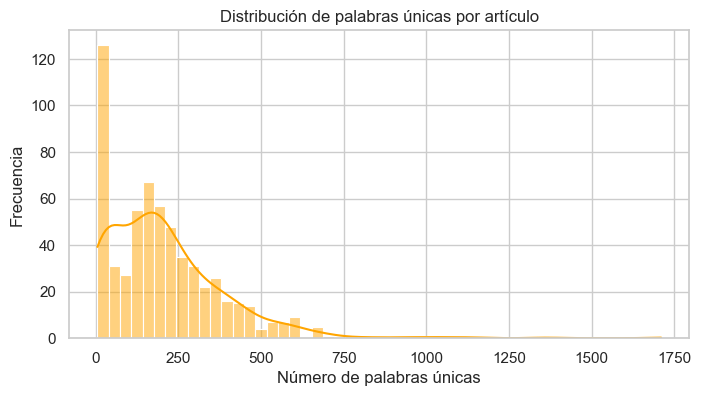

In [64]:
# 12) DISTRIBUCIÓN DE PALABRAS ÚNICAS POR ARTÍCULO
sentiment_data["unique_words"] = sentiment_data["full_content"].fillna("").apply(lambda x: len(set(x.split())))

plt.figure(figsize=(8,4))
sns.histplot(sentiment_data["unique_words"], bins=50, kde=True, color="orange")
plt.title("Distribución de palabras únicas por artículo")
plt.xlabel("Número de palabras únicas")
plt.ylabel("Frecuencia")
plt.show()

### Resultados

In [65]:
results_df = pd.read_csv("2_Modelos/sentiment/test_predictions.csv")
LABELS = ["negative", "neutral", "positive"]

In [66]:
y_true = results_df["true_label"]
y_pred = results_df["pred_label"]

print("=== MÉTRICAS GENERALES ===")
print(classification_report(y_true, y_pred, target_names=LABELS))

=== MÉTRICAS GENERALES ===
              precision    recall  f1-score   support

    negative       0.25      0.33      0.29         6
     neutral       0.76      0.61      0.67        46
    positive       0.24      0.40      0.30        10

    accuracy                           0.55        62
   macro avg       0.41      0.45      0.42        62
weighted avg       0.62      0.55      0.58        62



<Figure size 600x500 with 0 Axes>

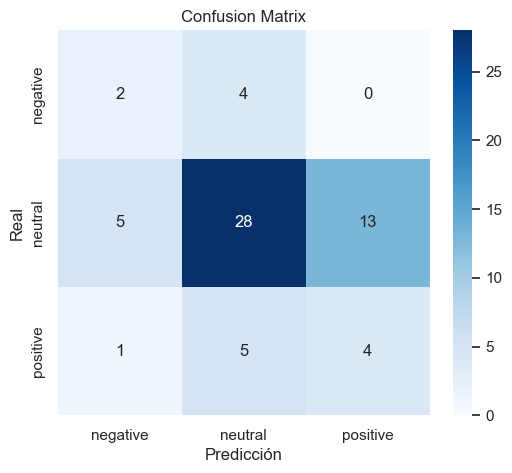

In [67]:
# === MATRIZ DE CONFUSIÓN ===
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_true, y_pred, labels=LABELS)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=LABELS, yticklabels=LABELS)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Confusion Matrix")
plt.show()

In [68]:
errors_df = results_df[results_df["true_label"] != results_df["pred_label"]][
    ["text", "true_label", "pred_label"]
].copy()

# Contar errores por combinación
error_counts = (
    errors_df.groupby(["true_label", "pred_label"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)
print("Errores más comunes:")
display(error_counts)

# Mostrar ejemplos aleatorios de errores
print("\nEjemplos de errores:")
display(errors_df.sample(min(5, len(errors_df)), random_state=42))

Errores más comunes:


,true_label,pred_label,count
2,neutral,positive,13
1,neutral,negative,5
4,positive,neutral,5
0,negative,neutral,4
3,positive,negative,1



Ejemplos de errores:


,text,true_label,pred_label
25,actor arbaz patel made headlines dynamic stint...,neutral,positive
59,michael b jordan big year headlined critically...,neutral,positive
23,texas longhorns head coach steve sarkisian rep...,neutral,positive
53,college football action heats cbs sports netwo...,neutral,positive
1,us president donald trump getting money renova...,positive,negative


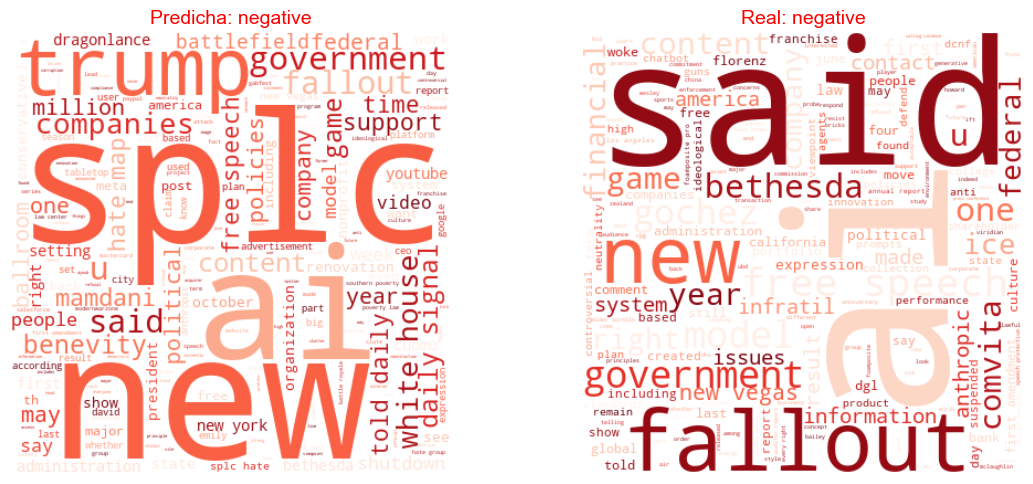

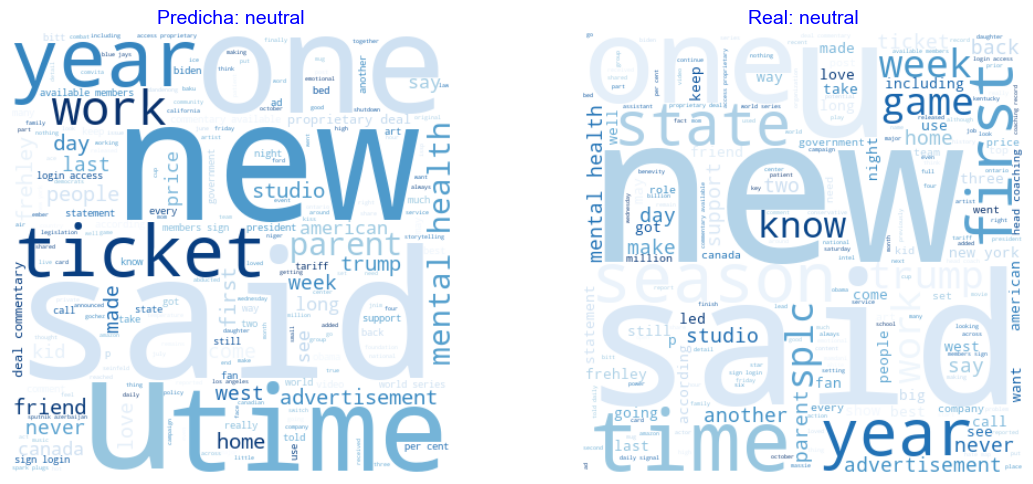

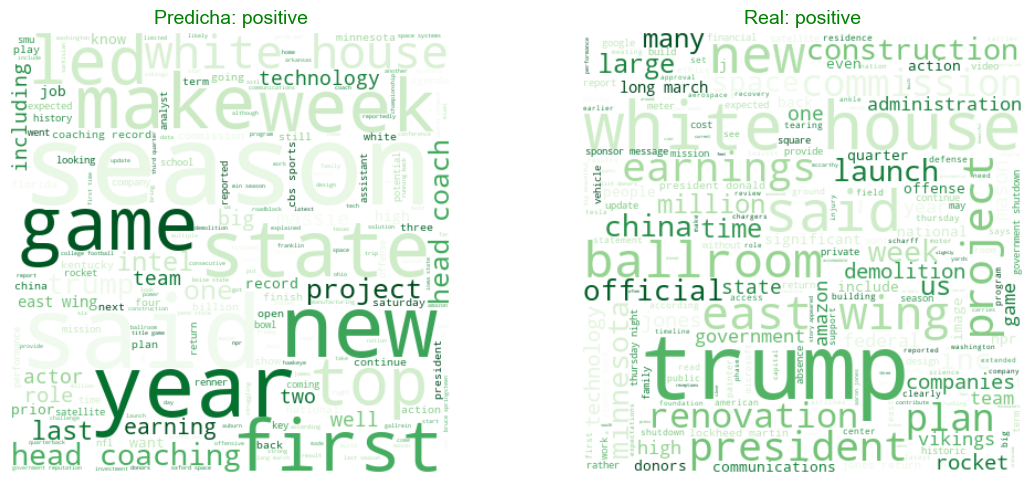

In [ ]:
LABEL2ID = {"negative": 0, "neutral": 1, "positive": 2}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}

def plot_wordcloud_side_by_side(results_df, label, col_text="text"):
    """
    Muestra nubes de palabras lado a lado:
    izquierda = predicha, derecha = real
    """
    cmap_dict = {"positive": "Greens", "neutral": "Blues", "negative": "Reds"}
    color_dict = {"positive": "green", "neutral": "blue", "negative": "red"}
    
    # Textos
    text_pred = " ".join(results_df[results_df["pred_label"] == label][col_text].astype(str))
    text_true = " ".join(results_df[results_df["true_label"] == label][col_text].astype(str))
    
    # Crear nubes
    wc_pred = WordCloud(width=400, height=400, background_color="white",
                        colormap=cmap_dict[label], max_words=200).generate(text_pred)
    wc_true = WordCloud(width=400, height=400, background_color="white",
                        colormap=cmap_dict[label], max_words=200).generate(text_true)
    
    # Subplots
    fig, axes = plt.subplots(1, 2, figsize=(12,5))
    axes[0].imshow(wc_pred, interpolation="bilinear")
    axes[0].axis("off")
    axes[0].set_title(f"Predicha: {label}", color=color_dict[label], fontsize=14)
    
    axes[1].imshow(wc_true, interpolation="bilinear")
    axes[1].axis("off")
    axes[1].set_title(f"Real: {label}", color=color_dict[label], fontsize=14)
    
    plt.tight_layout()
    plt.show()

# %%
# Mostrar nubes lado a lado para cada clase
for label in LABEL2ID.keys():
    plot_wordcloud_side_by_side(results_df, label)

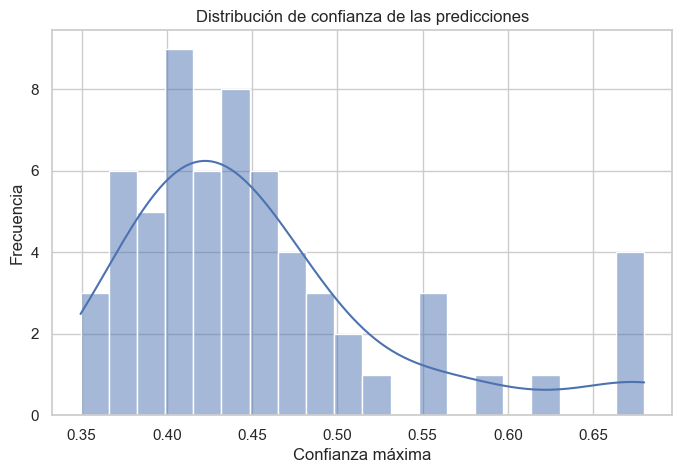

,text,true_label,pred_label,confidence
7,loading error loading face weak polling figure...,neutral,negative,0.349324
58,intel intc stock jumped friday chipmaker repor...,neutral,positive,0.358328
29,week anthropic ceo dario amodei publicly defen...,negative,negative,0.359223
15,earnings season ramping tesla tsla netflix nfl...,positive,positive,0.369670
1,us president donald trump getting money renova...,positive,negative,0.374569
4,week emily bazelon john dickerson david plotz ...,neutral,negative,0.376129
45,speaking fox news digital apple chief operatin...,neutral,neutral,0.376451
10,skip comments got new juicy details obama bide...,neutral,neutral,0.378636
28,faces stiff opposition scheme subject various ...,negative,neutral,0.379959
2,dragonlance endured one beloved worlds created...,neutral,negative,0.385569


In [70]:
# === Crear columna de pred_probs ===
results_df["pred_probs"] = results_df[["prob_negative", "prob_neutral", "prob_positive"]].values.tolist()

# Calcular confianza máxima
max_probs = results_df["pred_probs"].apply(lambda x: max(x))

# === DISTRIBUCIÓN DE CONFIANZA ===
plt.figure(figsize=(8,5))
sns.histplot(max_probs, bins=20, kde=True)
plt.title("Distribución de confianza de las predicciones")
plt.xlabel("Confianza máxima")
plt.ylabel("Frecuencia")
plt.show()

# === EJEMPLOS DE BAJA CONFIANZA ===
low_conf_df = results_df[["text", "true_label", "pred_label"]].copy()
low_conf_df["confidence"] = max_probs

# Mostrar los 10 con menor confianza
display(low_conf_df.sort_values("confidence").head(10))